In [1]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
roots_tfm = '/home/julien/Documents/Etudes/Astrofisica/Master/TFM/Data'

In [2]:
#df = dd.read_csv(roots_tfm + '/Galex/GUVCat_AIS_FOV055_glat50_00N__55_00N.csv', \
#                 names=['objid','ra','dec','tilenum','nuv_flux','nuv_fluxerr', \
#                         'fuv_flux','fuv_fluxerr','nuv_poserr'],header=0)
#df = pd.read_csv(roots_tfm + '/Galex/GUVCat_AIS_FOV055_glat50_00N__55_00N_lite.csv')
#df = pd.read_csv(roots_tfm + '/Galex/GUVCat_AIS_FOV055_glat05_00N__10_00N_lite.csv')
df = pd.read_csv(roots_tfm + '/Galex/match_Galex_UVOT_OM_best.csv')
df_all = pd.read_csv(roots_tfm + '/Galex/match_Galex_UVOT_OM_all.csv')

In [3]:
df.head()

,objid,ra_1,dec_1,fuv_flux,fuv_fluxerr,nuv_flux,nuv_fluxerr,nuv_poserr,SRCNUM_OM,SRCNUM_UVOT,RA_2,DEC_2,POSERR,COUNT,angDist
0,6373097221993268460,83.884105,40.187670,27.279566,3.999979,29.566187,4.045698,0.625514,0,1014525,83.883805,40.187728,0.358525,3,0.852187
1,6371795405592593744,330.548352,66.793384,-999.000000,-999.000000,10.336556,2.764180,1.608465,0,5880541,330.547788,66.793715,0.184504,3,1.434355
2,6373976851694487732,100.268286,26.473098,-999.000000,-999.000000,3.807085,1.412635,1.266602,0,1320921,100.267939,26.473093,0.611849,1,1.119616
3,6373976851696585056,100.261757,26.502480,3.971011,1.676836,6.980900,1.855379,1.075492,0,1320711,100.262181,26.502354,0.489386,4,1.438630
4,6373976851696586502,100.349042,26.694327,10.779969,3.866972,25.672947,4.400514,1.088975,0,1323941,100.349435,26.693479,0.391472,6,3.304391


In [4]:
df=df.replace(-999,np.nan)

In [5]:
df.shape

(227545, 15)

In [6]:
df_all.shape

(244443, 15)

In [7]:
df_merge = df_all[df_all.duplicated(subset=['objid'])].merge(df,on='objid')
df['SUSPICIOUS_MATCH'] = False
df.loc[df['objid'].isin(df_merge['objid']),'SUSPICIOUS_MATCH'] = True

In [8]:
df.dtypes

objid                 int64
ra_1                float64
dec_1               float64
fuv_flux            float64
fuv_fluxerr         float64
nuv_flux            float64
nuv_fluxerr         float64
nuv_poserr          float64
SRCNUM_OM             int64
SRCNUM_UVOT           int64
RA_2                float64
DEC_2               float64
POSERR              float64
COUNT                 int64
angDist             float64
SUSPICIOUS_MATCH       bool
dtype: object

In [9]:
df = df.rename(columns={'ra_1':'RA','dec_1':'DEC','nuv_poserr':'POSERR','objid':'SRCNUM',\
                       'nuv_flux':'NUV_FLUX', 'nuv_fluxerr' : 'NUV_FLUX_ERR', \
                         'fuv_flux': 'FUV_FLUX','fuv_fluxerr' : 'FUV_FLUX_ERR'})

In [10]:
df.head()

,SRCNUM,RA,DEC,FUV_FLUX,FUV_FLUX_ERR,NUV_FLUX,NUV_FLUX_ERR,POSERR,SRCNUM_OM,SRCNUM_UVOT,RA_2,DEC_2,POSERR,COUNT,angDist,SUSPICIOUS_MATCH
0,6373097221993268460,83.884105,40.187670,27.279566,3.999979,29.566187,4.045698,0.625514,0,1014525,83.883805,40.187728,0.358525,3,0.852187,False
1,6371795405592593744,330.548352,66.793384,NaN,NaN,10.336556,2.764180,1.608465,0,5880541,330.547788,66.793715,0.184504,3,1.434355,False
2,6373976851694487732,100.268286,26.473098,NaN,NaN,3.807085,1.412635,1.266602,0,1320921,100.267939,26.473093,0.611849,1,1.119616,False
3,6373976851696585056,100.261757,26.502480,3.971011,1.676836,6.980900,1.855379,1.075492,0,1320711,100.262181,26.502354,0.489386,4,1.438630,False
4,6373976851696586502,100.349042,26.694327,10.779969,3.866972,25.672947,4.400514,1.088975,0,1323941,100.349435,26.693479,0.391472,6,3.304391,False


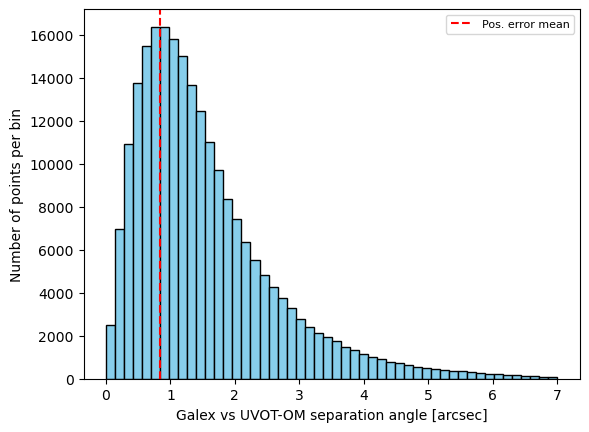

In [22]:
# Plot figure
fig, ax =plt.subplots()
(n,bins,patches) = ax.hist(df[df['angDist']<7]['angDist'], bins=50, color='skyblue',edgecolor='black')
ax.axvline(np.mean(df['POSERR']), linestyle='dashed', color='r',label='Pos. error mean')
ax.set_xlabel("Galex vs UVOT-OM separation angle [arcsec]")
ax.set_ylabel("Number of points per bin")
ax.legend(prop={'size': 8})
fig.savefig(roots_tfm + '/Galex/match_Galex_UVOT_OM.png',dpi=1200)  

In [23]:
filepath_count = roots_tfm + '/Galex/count_random_match.txt'
df_count = pd.read_csv(filepath_count,sep=' ',skiprows=[0],header=None,usecols=[5])
sum = 0
i=0
while sum<(df.shape[0] - df_count[5].sum()):
    sum = sum + n[i]
    i=i+1
print("Sum of cumulated matchs until bin number " + str(i) + " : " + str(sum))
print("Corresponding maximum angle : {:.2E}".format(bins[i]))

Sum of cumulated matchs until bin number 45 : 226655.0
Corresponding maximum angle : 6.30E+00


In [24]:
df = df[df['angDist']<5]
df.shape

(223743, 16)

In [25]:
df = df.astype({'SRCNUM': np.int64, 'NUV_FLUX': np.float32, 'FUV_FLUX': np.float32, \
                'NUV_FLUX_ERR': np.float32, 'FUV_FLUX_ERR': np.float32, 'RA': np.float64, \
                'DEC': np.float64, 'POSERR': np.float32})

In [27]:
df_radec = df[['RA','DEC','POSERR','SRCNUM']]
df_radec.shape

In [35]:
df_entries = df[['SRCNUM','NUV_FLUX','NUV_FLUX_ERR','FUV_FLUX','FUV_FLUX_ERR','SRCNUM_UVOT']]

In [30]:
dat_UVOT=pd.read_csv(roots_tfm + '/Swift-UVOT/Entries_UVOT_galaxies.csv')

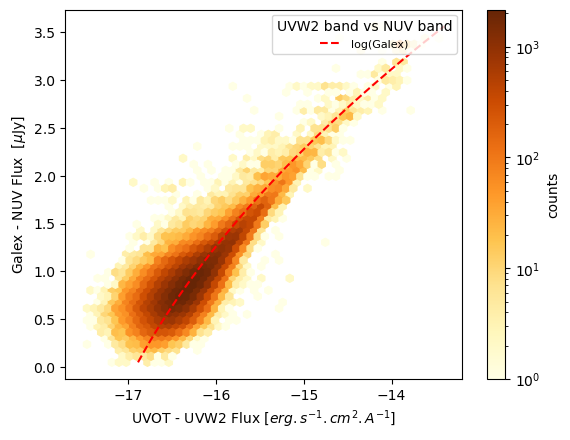

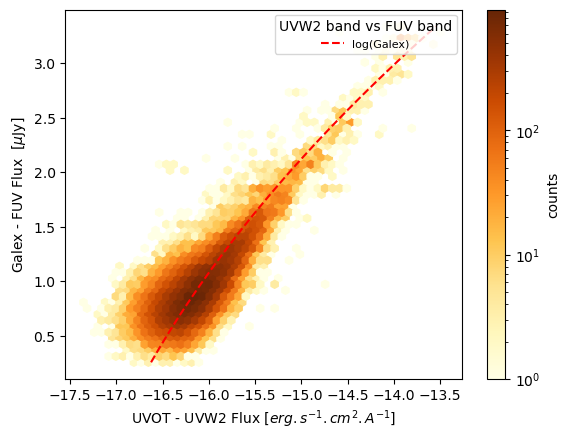

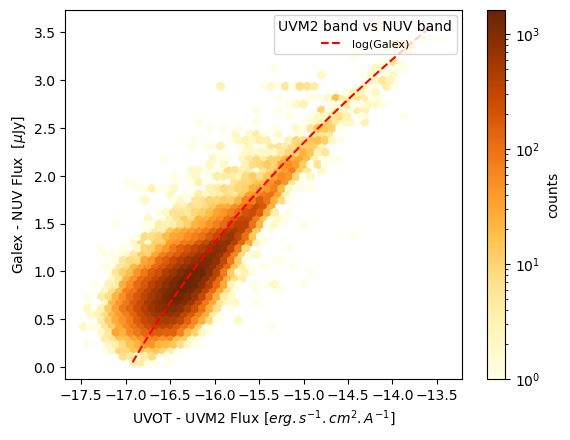

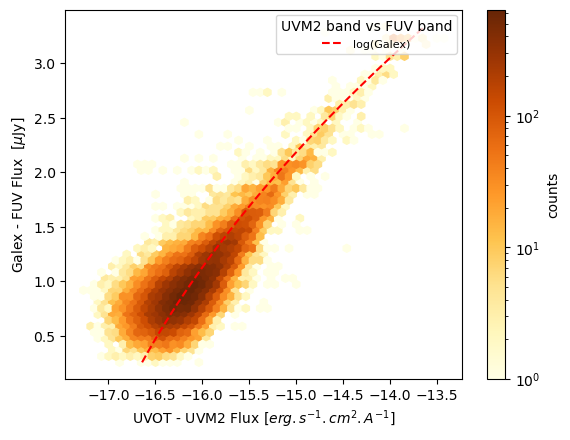

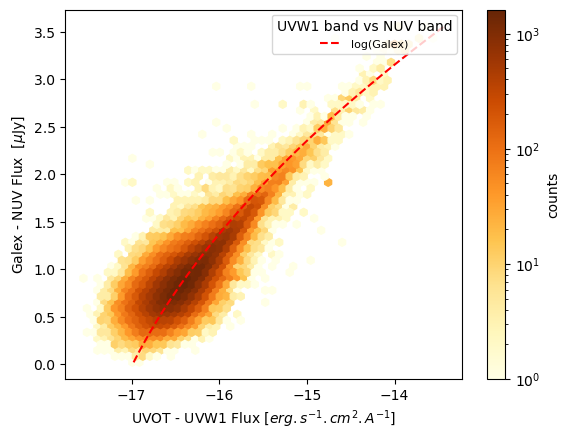

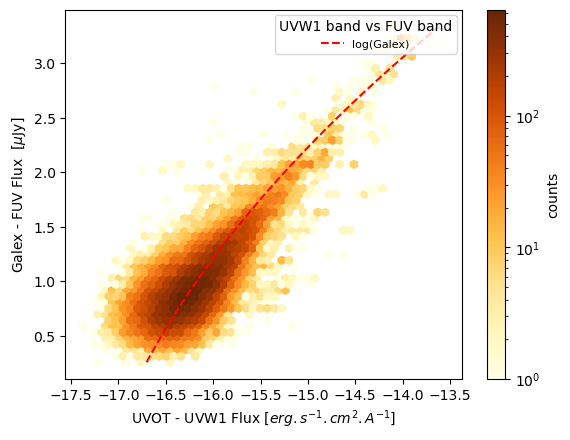

In [41]:
for flux in ['UVW2','UVM2','UVW1']: 
  
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_uvot = df_flux_uvot[df_flux_uvot[flux_quality] == 0]

    for flux_galex in ['NUV','FUV']:
        
        flux_galex_name = flux_galex + '_FLUX'
        flux_galex_err = flux_galex + '_FLUX_ERR'

         # Data frame Galex for this band
        df_flux_galex = df_entries[['SRCNUM',flux_galex_name,flux_galex_err,'SRCNUM_UVOT']].dropna(subset=[flux_galex_name])
        df_flux_galex = df_flux_galex[df_flux_galex['SRCNUM_UVOT'] != 0]
        df_flux_galex=df_flux_galex.reset_index().rename(columns={'SRCNUM': 'SRCNUM_GALEX'})

        # Merge with UVOT results
        df_merge = df_flux_galex.merge(df_flux_uvot, left_on='SRCNUM_UVOT', right_on='SRCNUM')

        # Plot figure
        fig, ax =plt.subplots()
        x=np.log10(df_merge[flux_name])
        y=np.log10(df_merge[flux_galex_name])
        hb =ax.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr')
        cb = fig.colorbar(hb, ax=ax, label='counts')
        
        x=np.log10(df_merge.loc[:,flux_name])
        y=np.log10(df_merge.loc[:,flux_galex_name]) 
        p = np.poly1d(np.polyfit(y,x, deg=2))
        yp = np.linspace(y.min(), y.max(), 100)
        ax.plot(p(yp), yp, color='r', linestyle='dashed', label= "log(Galex)")   

        df_entries.loc[:,flux_galex + '_' + flux + '_FLUX'] = 10**p(np.log10(df_entries.loc[:,flux_galex_name]))
        
        ax.set_xlabel("UVOT - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
        ax.set_ylabel("Galex - " + flux_galex + ' Flux  [' + "$\mu$" +"Jy]")
        ax.legend(loc='upper right',prop={'size': 8},title= flux + " band vs " + flux_galex + " band")
        fig.savefig(roots_tfm + '/Calibration/UVOT_' + flux + '_vs_Galex_ ' + flux_galex + "_all_galaxies.png",dpi=1200)  

In [37]:
df_merge.head()

,index_x,SRCNUM_GALEX,NUV_FLUX,NUV_FLUX_ERR,SRCNUM_UVOT,index_y,SRCNUM,UVW2_FLUX,UVW2_FLUX_ERR,UVW2_EXTENDED,UVW2_QUALITY_FLAG
0,0,6373097221993268460,29.566187,4.045698,1014525,178310,1014525,1.478643e-16,1.610919e-17,False,0
1,5,6381682203412142658,5.499908,2.375631,1771253,236526,1771253,5.970058e-17,5.849914e-18,False,0
2,6,6381682203412142685,12.761661,3.354586,1773788,236694,1773788,6.112437e-17,6.462544e-18,False,0
3,7,6381682203412142689,13.291240,4.638354,1773142,236641,1773142,8.777969e-17,7.495578e-18,False,0
4,8,6381682203412142774,6.375251,2.776090,1778818,237298,1778818,5.454454e-17,5.820332e-18,False,0


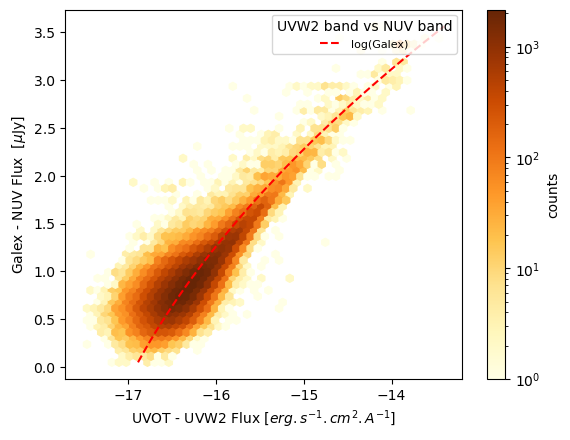

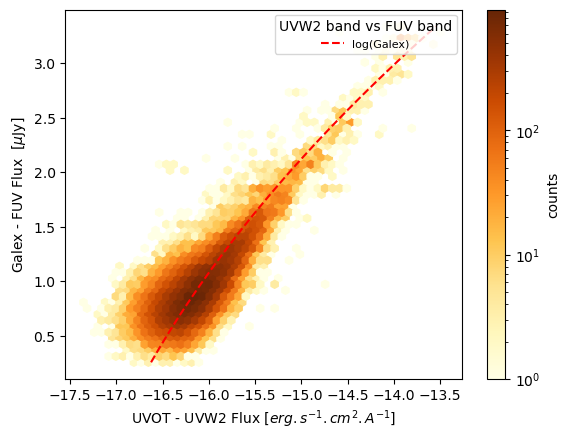

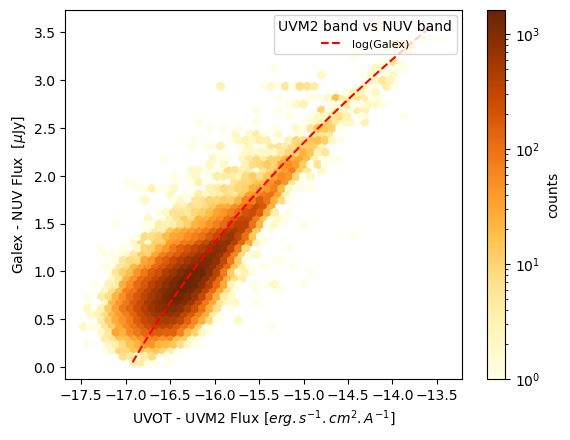

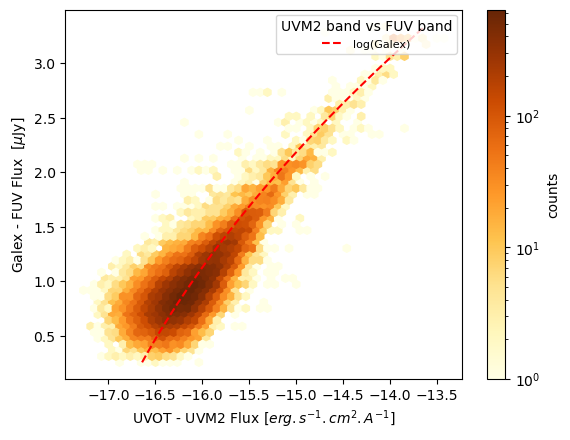

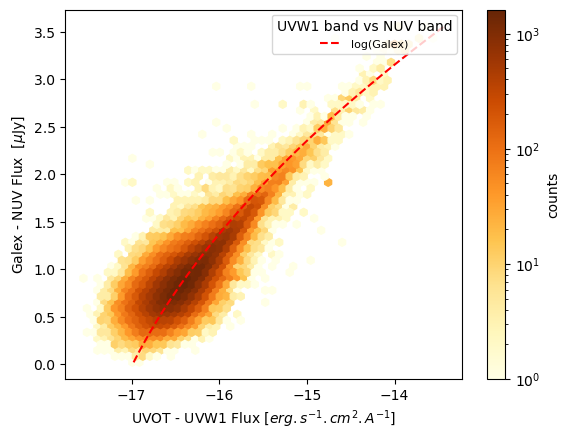

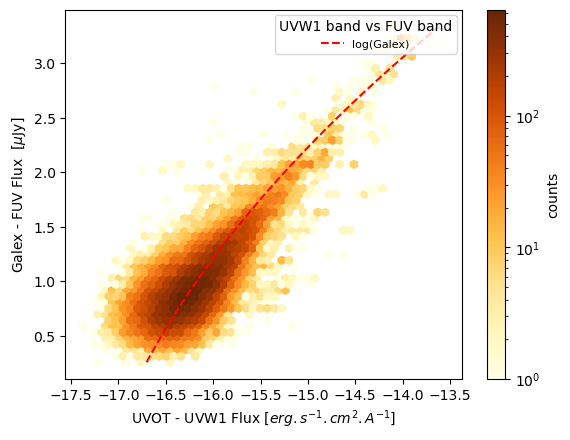

In [42]:
for flux in ['UVW2','UVM2','UVW1']: 
  
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe UVOT for this band
    df_flux_uvot = dat_UVOT[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_uvot = df_flux_uvot[df_flux_uvot[flux_quality] == 0]

    for flux_galex in ['NUV','FUV']:
        
        flux_galex_name = flux_galex + '_FLUX'
        flux_galex_err = flux_galex + '_FLUX_ERR'

         # Data frame Galex for this band
        df_flux_galex = df_entries[['SRCNUM',flux_galex_name,flux_galex_err,'SRCNUM_UVOT']].dropna(subset=[flux_galex_name])
        df_flux_galex = df_flux_galex[df_flux_galex['SRCNUM_UVOT'] != 0]
        df_flux_galex=df_flux_galex.reset_index().rename(columns={'SRCNUM': 'SRCNUM_GALEX'})

        # Merge with UVOT results
        df_merge = df_flux_galex.merge(df_flux_uvot, left_on='SRCNUM_UVOT', right_on='SRCNUM')

        # Plot figure
        fig, ax =plt.subplots()
        x=np.log10(df_merge[flux_name])
        y=np.log10(df_merge[flux_galex_name])
        hb =ax.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr')
        cb = fig.colorbar(hb, ax=ax, label='counts')
        
        x=np.log10(df_merge.loc[:,flux_name])
        y=np.log10(df_merge.loc[:,flux_galex_name]) 
        p = np.poly1d(np.polyfit(y,x, deg=2))
        yp = np.linspace(y.min(), y.max(), 100)
        ax.plot(p(yp), yp, color='r', linestyle='dashed', label= "log(Galex)")   
        
        ax.set_xlabel("UVOT - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
        ax.set_ylabel("Galex - " + flux_galex + ' Flux  [' + "$\mu$" +"Jy]")
        ax.legend(loc='upper right',prop={'size': 8},title= flux + " band vs " + flux_galex + " band")

In [ ]:
db_path ='sqlite:///'+ roots_tfm + '/UVCatalogue.db'
df_entries_galex.to_sql("Entries_GALEX", db_path, if_exists='replace', index=False, chunksize=1000, method="multi")